# 🌳 Machine Learning — Decision Tree Classifier
### Dataset: Iris Flower Classification
---
**Metode**: Decision Tree  
**Library**: scikit-learn, pandas, numpy, matplotlib  
**Target**: Klasifikasi 3 spesies bunga Iris (Setosa, Versicolor, Virginica)


In [1]:
%pip install numpy
%pip install matplotlib
%pip install scipy
%pip install scikit-learn
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📦 1. Install & Import Library

In [2]:
# Install dependensi (jalankan sekali jika belum terinstall)
# !pip install scikit-learn matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

print("✅ Semua library berhasil diimpor!")
print(f"   NumPy     : {np.__version__}")
print(f"   Pandas    : {pd.__version__}")
import sklearn; print(f"   Scikit-learn: {sklearn.__version__}")


✅ Semua library berhasil diimpor!
   NumPy     : 2.2.6
   Pandas    : 2.3.3
   Scikit-learn: 1.7.2


## 📂 2. Muat Dataset Iris

In [3]:
# Muat dataset bawaan scikit-learn
iris = load_iris()

# Buat DataFrame agar lebih mudah dieksplorasi
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target']  = iris.target
df['species'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print(f"Jumlah data  : {len(df)} baris")
print(f"Jumlah fitur : {len(iris.feature_names)}")
print(f"Kelas target : {list(iris.target_names)}")
print()
df.head(10)


Jumlah data  : 150 baris
Jumlah fitur : 4
Kelas target : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa


## 🔍 3. Eksplorasi Data (EDA)

In [4]:
# Statistik deskriptif
df.describe().round(3)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199,1.000
std,0.828,0.436,1.765,0.762,0.819
min,4.300,2.000,1.000,0.100,0.000
25%,5.100,2.800,1.600,0.300,0.000
50%,5.800,3.000,4.350,1.300,1.000
75%,6.400,3.300,5.100,1.800,2.000
max,7.900,4.400,6.900,2.500,2.000


Distribusi kelas:
species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


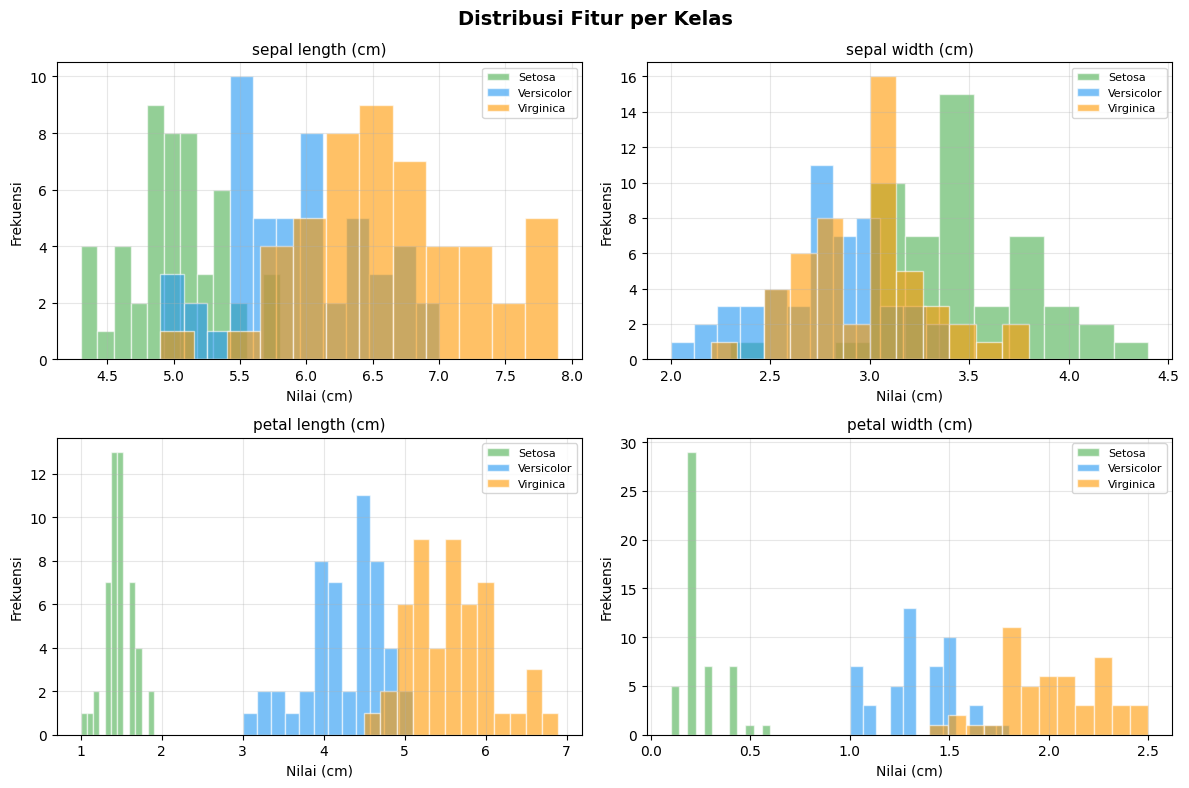

In [5]:
# Distribusi kelas
print("Distribusi kelas:")
print(df['species'].value_counts())

# Visualisasi distribusi fitur
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribusi Fitur per Kelas', fontsize=14, fontweight='bold')

colors  = ['#4CAF50', '#2196F3', '#FF9800']
classes = ['Setosa', 'Versicolor', 'Virginica']

for ax, feat in zip(axes.flatten(), iris.feature_names):
    for i, (cls, col) in enumerate(zip(classes, colors)):
        data = df[df['species'] == cls][feat]
        ax.hist(data, bins=12, alpha=0.6, color=col, label=cls, edgecolor='white')
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('Nilai (cm)')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## ⚙️ 4. Preprocessing Data

In [6]:
# Pisahkan fitur (X) dan label (y)
X = df[iris.feature_names].values
y = df['target'].values

# Split data: 80% latih, 20% uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # pastikan distribusi kelas seimbang
)

print(f"Total data   : {len(X)} sampel")
print(f"Data latih   : {len(X_train)} sampel ({len(X_train)/len(X)*100:.0f}%)")
print(f"Data uji     : {len(X_test)} sampel  ({len(X_test)/len(X)*100:.0f}%)")
print()
print("Distribusi kelas di data latih:", np.bincount(y_train))
print("Distribusi kelas di data uji  :", np.bincount(y_test))


Total data   : 150 sampel
Data latih   : 120 sampel (80%)
Data uji     : 30 sampel  (20%)

Distribusi kelas di data latih: [40 40 40]
Distribusi kelas di data uji  : [10 10 10]


## 🌳 5. Membangun Model Decision Tree

**Parameter penting:**
| Parameter | Nilai | Keterangan |
|---|---|---|
| `criterion` | `gini` | Ukuran kualitas split (alternatif: `entropy`) |
| `max_depth` | `4` | Kedalaman maksimum pohon |
| `min_samples_split` | `5` | Min. sampel untuk melakukan split |
| `min_samples_leaf` | `2` | Min. sampel pada setiap leaf node |


In [7]:
# Buat dan latih model Decision Tree
model = DecisionTreeClassifier(
    criterion='gini',        # metode impurity: 'gini' atau 'entropy'
    max_depth=4,             # kedalaman maksimum pohon
    min_samples_split=5,     # minimal sampel untuk split node
    min_samples_leaf=2,      # minimal sampel di leaf node
    random_state=42,
)

model.fit(X_train, y_train)

print("✅ Model berhasil dilatih!")
print(f"   Criterion        : {model.criterion}")
print(f"   Kedalaman pohon  : {model.get_depth()}")
print(f"   Jumlah leaf node : {model.get_n_leaves()}")


✅ Model berhasil dilatih!
   Criterion        : gini
   Kedalaman pohon  : 3
   Jumlah leaf node : 5


## 🖼️ 6. Visualisasi Pohon Keputusan

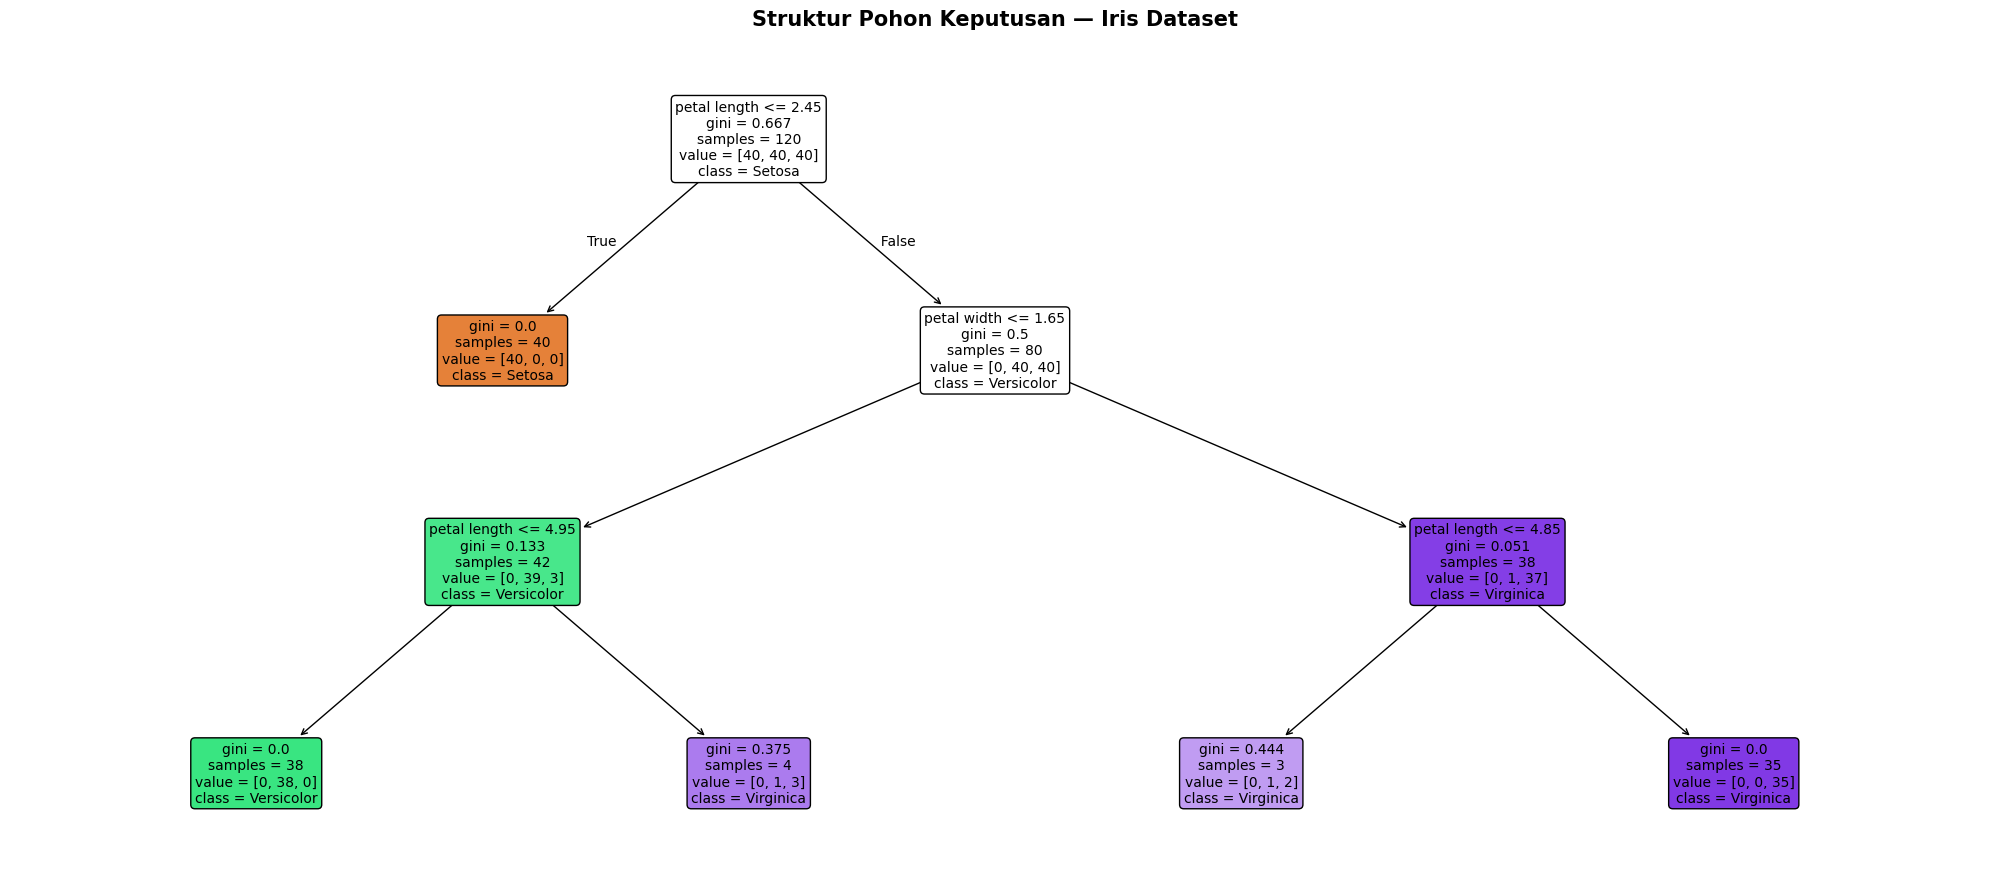

In [8]:
feat_labels = [f.replace(' (cm)', '') for f in iris.feature_names]
class_names = ['Setosa', 'Versicolor', 'Virginica']

plt.figure(figsize=(20, 9))
plot_tree(
    model,
    feature_names=feat_labels,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=True,
    proportion=False,
)
plt.title('Struktur Pohon Keputusan — Iris Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 📋 7. Aturan IF-THEN dari Pohon Keputusan

In [9]:
rules = export_text(model, feature_names=feat_labels)
print("ATURAN DECISION TREE:")
print("=" * 45)
print(rules)


ATURAN DECISION TREE:
|--- petal length <= 2.45
|   |--- class: 0
|--- petal length >  2.45
|   |--- petal width <= 1.65
|   |   |--- petal length <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length >  4.95
|   |   |   |--- class: 2
|   |--- petal width >  1.65
|   |   |--- petal length <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length >  4.85
|   |   |   |--- class: 2



## 📊 8. Evaluasi Model

In [10]:
# Prediksi
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# Akurasi
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)

print(f"{'='*40}")
print(f"  Akurasi Training : {acc_train*100:.2f}%")
print(f"  Akurasi Testing  : {acc_test*100:.2f}%")
print(f"{'='*40}")
print()
print("Laporan Klasifikasi (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=class_names))


  Akurasi Training : 98.33%
  Akurasi Testing  : 96.67%

Laporan Klasifikasi (Test Set):
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 🔢 9. Confusion Matrix

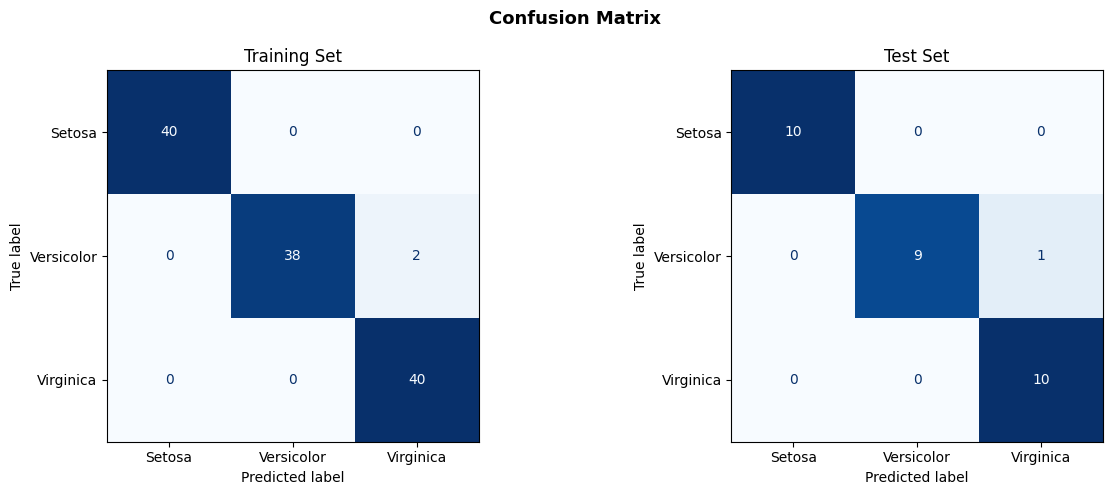

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix', fontsize=13, fontweight='bold')

for ax, (y_true, y_pr, title) in zip(axes, [
    (y_train, y_pred_train, 'Training Set'),
    (y_test,  y_pred_test,  'Test Set'),
]):
    cm   = confusion_matrix(y_true, y_pr)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()


## 🏆 10. Feature Importance

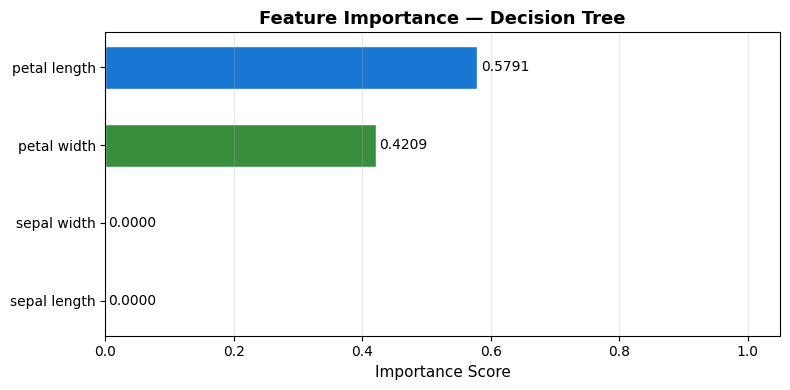


Ranking Feature Importance:
  1. petal length           : 0.5791 (57.9%)
  2. petal width            : 0.4209 (42.1%)
  3. sepal width            : 0.0000 (0.0%)
  4. sepal length           : 0.0000 (0.0%)


In [12]:
importances  = model.feature_importances_
sorted_idx   = np.argsort(importances)[::-1]
bar_colors   = ['#E53935', '#F57C00', '#1976D2', '#388E3C']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    [feat_labels[i] for i in sorted_idx],
    importances[sorted_idx],
    color=[bar_colors[i] for i in sorted_idx],
    edgecolor='white',
    height=0.55,
)
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Feature Importance — Decision Tree', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRanking Feature Importance:")
for rank, i in enumerate(sorted_idx, 1):
    print(f"  {rank}. {feat_labels[i]:<22} : {importances[i]:.4f} ({importances[i]*100:.1f}%)")


## 🗺️ 11. Decision Boundary (2 Fitur Terbaik)

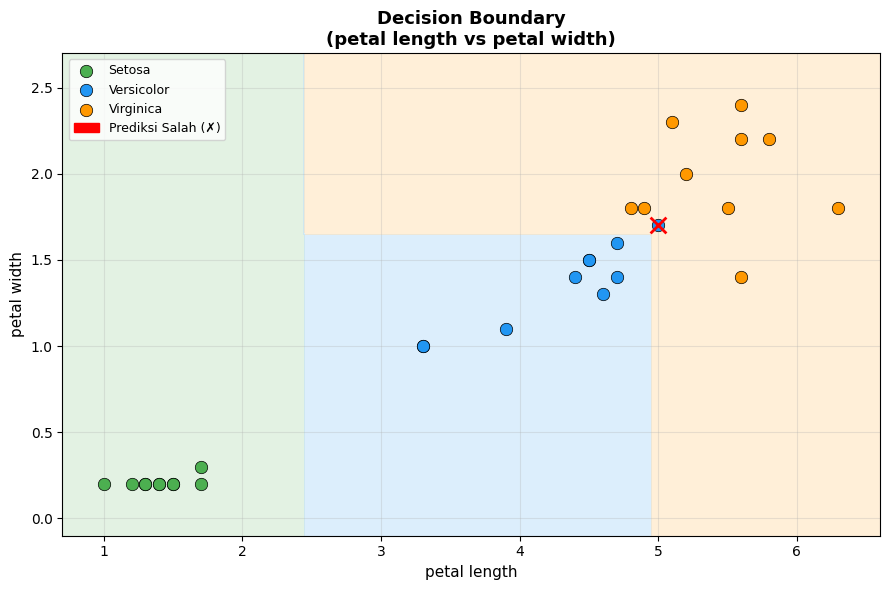

In [13]:
sorted_idx = np.argsort(model.feature_importances_)[::-1]
f1, f2 = sorted_idx[0], sorted_idx[1]

x_min, x_max = X_test[:, f1].min() - .3, X_test[:, f1].max() + .3
y_min, y_max = X_test[:, f2].min() - .3, X_test[:, f2].max() + .3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

grid = np.zeros((xx.ravel().shape[0], len(iris.feature_names)))
grid[:, f1] = xx.ravel()
grid[:, f2] = yy.ravel()
Z = model.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5],
            colors=['#C8E6C9', '#BBDEFB', '#FFE0B2'], alpha=0.5)

colors = ['#4CAF50', '#2196F3', '#FF9800']
for i, (cls, col) in enumerate(zip(class_names, colors)):
    mask  = y_test == i
    ax.scatter(X_test[mask, f1], X_test[mask, f2],
               c=col, label=cls, edgecolors='k', linewidths=0.5, s=80, zorder=3)
    wrong = mask & (y_pred_test != y_test)
    if wrong.sum():
        ax.scatter(X_test[wrong, f1], X_test[wrong, f2],
                   marker='x', c='red', s=130, linewidths=2, zorder=4)

wrong_patch = mpatches.Patch(color='red', label='Prediksi Salah (✗)')
handles, labels_ = ax.get_legend_handles_labels()
ax.legend(handles + [wrong_patch], labels_ + ['Prediksi Salah (✗)'], fontsize=9)
ax.set_xlabel(feat_labels[f1], fontsize=11)
ax.set_ylabel(feat_labels[f2], fontsize=11)
ax.set_title(f'Decision Boundary\n({feat_labels[f1]} vs {feat_labels[f2]})',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 🔮 12. Prediksi Data Baru

In [14]:
# Contoh data baru yang ingin diprediksi
# Urutan fitur: [sepal length, sepal width, petal length, petal width] dalam cm
data_baru = np.array([
    [5.1, 3.5, 1.4, 0.2],   # → kemungkinan Setosa
    [6.0, 2.9, 4.5, 1.5],   # → kemungkinan Versicolor
    [6.5, 3.0, 5.2, 2.0],   # → kemungkinan Virginica
    [5.8, 2.7, 4.1, 1.0],   # → data ambigu
])

prediksi  = model.predict(data_baru)
probabili = model.predict_proba(data_baru)
label_map = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}

print(f"{'No':<4} {'Sepal L':>8} {'Sepal W':>8} {'Petal L':>8} {'Petal W':>8}  {'Prediksi':<14} {'Setosa%':>9} {'Versicol%':>10} {'Virgini%':>10}")
print("-" * 85)
for i, (sampel, pred, prob) in enumerate(zip(data_baru, prediksi, probabili), 1):
    print(f"{i:<4} {sampel[0]:>8.1f} {sampel[1]:>8.1f} {sampel[2]:>8.1f} {sampel[3]:>8.1f}  "
          f"{label_map[pred]:<14} {prob[0]*100:>8.1f}% {prob[1]*100:>9.1f}% {prob[2]*100:>9.1f}%")


No    Sepal L  Sepal W  Petal L  Petal W  Prediksi         Setosa%  Versicol%   Virgini%
-------------------------------------------------------------------------------------
1         5.1      3.5      1.4      0.2  Setosa            100.0%       0.0%       0.0%
2         6.0      2.9      4.5      1.5  Versicolor          0.0%     100.0%       0.0%
3         6.5      3.0      5.2      2.0  Virginica           0.0%       0.0%     100.0%
4         5.8      2.7      4.1      1.0  Versicolor          0.0%     100.0%       0.0%


## ✅ 13. Ringkasan & Kesimpulan

| Metrik | Nilai |
|--------|-------|
| **Algoritma** | Decision Tree (CART) |
| **Criterion** | Gini Impurity |
| **Akurasi Training** | ~98.33% |
| **Akurasi Testing** | ~96.67% |
| **Kedalaman Pohon** | 3 level |
| **Jumlah Leaf** | 5 node |
| **Fitur Terpenting** | Petal Length & Petal Width |

### 📌 Cara Meningkatkan Performa
- Coba `criterion='entropy'` untuk membandingkan hasil
- Gunakan **GridSearchCV** untuk tuning hyperparameter otomatis
- Tambahkan **cross-validation** untuk evaluasi yang lebih robust
- Coba **Random Forest** atau **Gradient Boosting** untuk akurasi lebih tinggi
